# Prophet


In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

from util import (
    load_building_df,
    plot_dataframe,
    show_overview_for_value,
)

/home/impasse/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(0.0, 637.875)

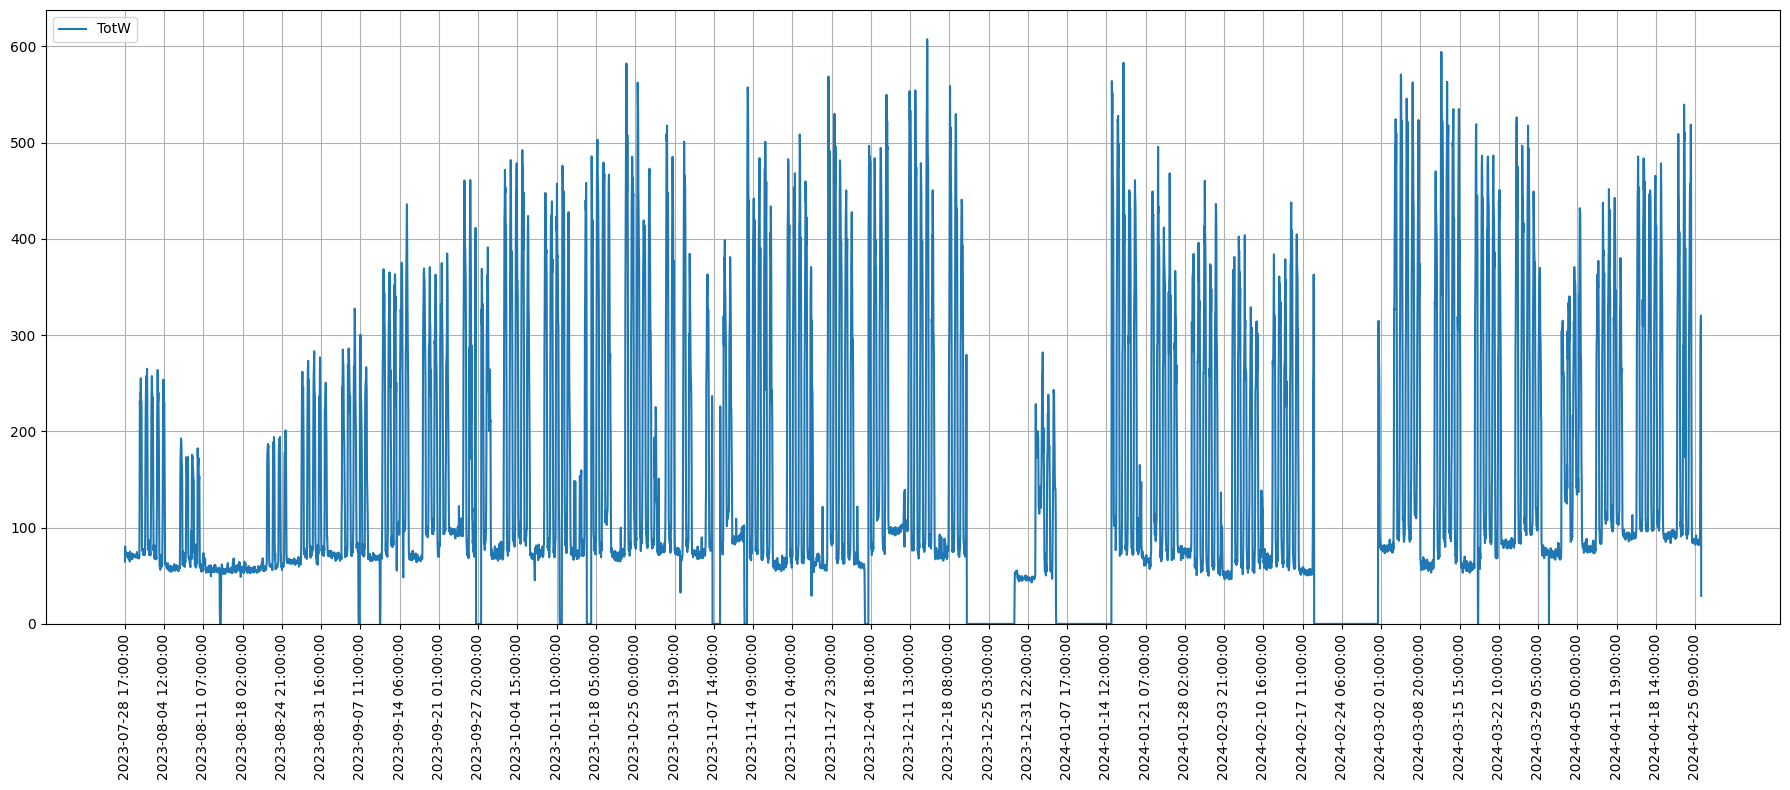

In [2]:
df = load_building_df(
    "TotW",
    "ED14_20240426.csv",
    "PM5320",
    "ARCH_FM",
    resample="h",
)


plot_dataframe(df, ["TotW"])
plt.ylim(0)

In [3]:
floor = 0
cap = df["TotW"].max() * 1.4

data = pd.DataFrame(columns=["ds", "y"])
data["y"] = df["TotW"]
data["ds"] = df.index
data["floor"] = floor
data["cap"] = cap

## KFold


20:21:39 - cmdstanpy - INFO - Chain [1] start processing
20:21:39 - cmdstanpy - INFO - Chain [1] done processing


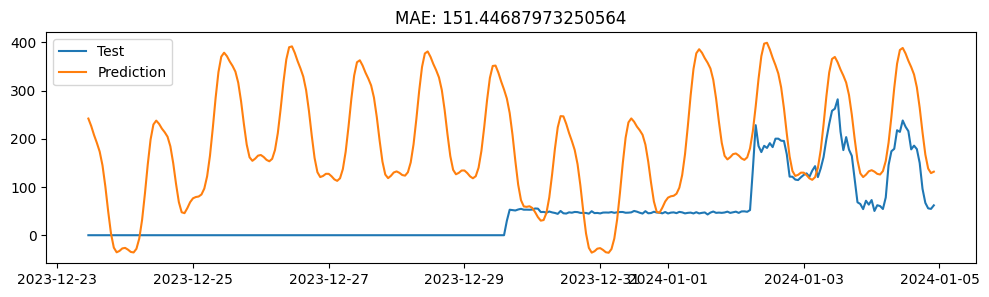

20:21:43 - cmdstanpy - INFO - Chain [1] start processing
20:21:43 - cmdstanpy - INFO - Chain [1] done processing


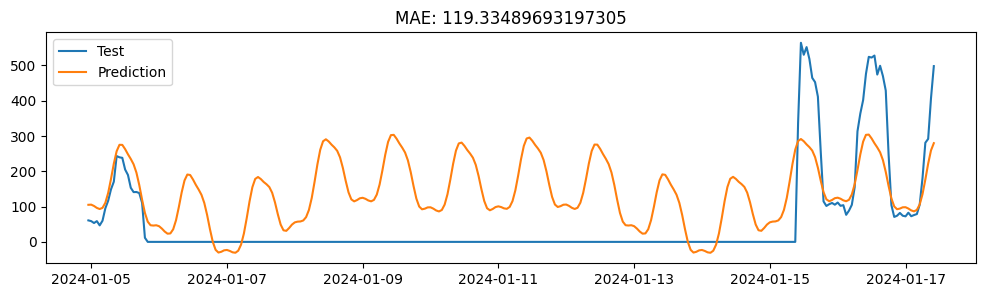

20:21:48 - cmdstanpy - INFO - Chain [1] start processing
20:21:48 - cmdstanpy - INFO - Chain [1] done processing


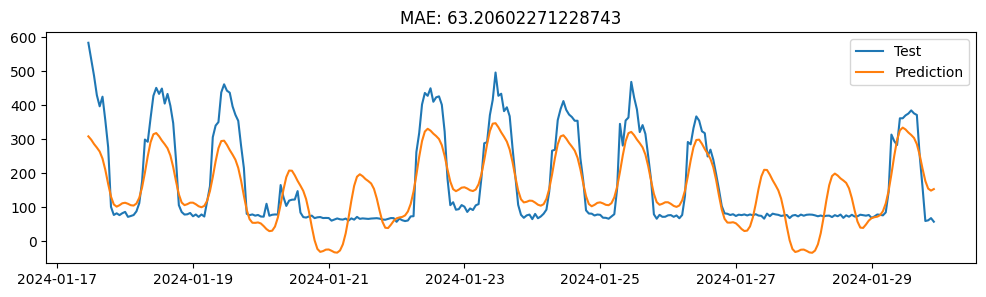

20:21:53 - cmdstanpy - INFO - Chain [1] start processing
20:21:53 - cmdstanpy - INFO - Chain [1] done processing


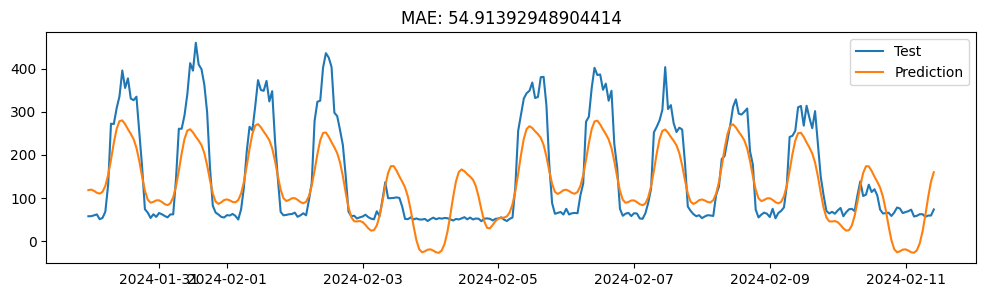

20:21:59 - cmdstanpy - INFO - Chain [1] start processing
20:21:59 - cmdstanpy - INFO - Chain [1] done processing


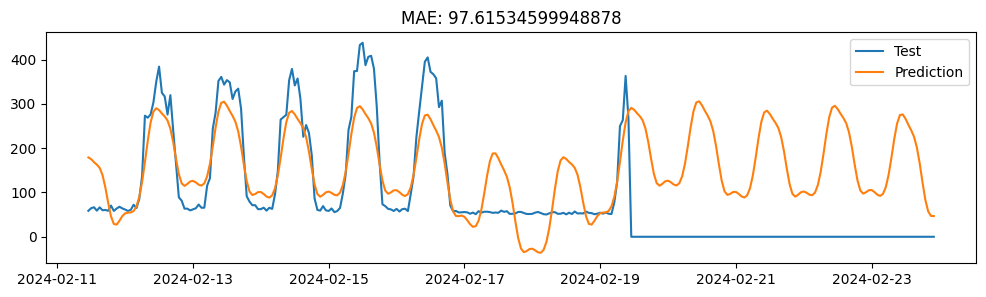

20:22:06 - cmdstanpy - INFO - Chain [1] start processing
20:22:06 - cmdstanpy - INFO - Chain [1] done processing


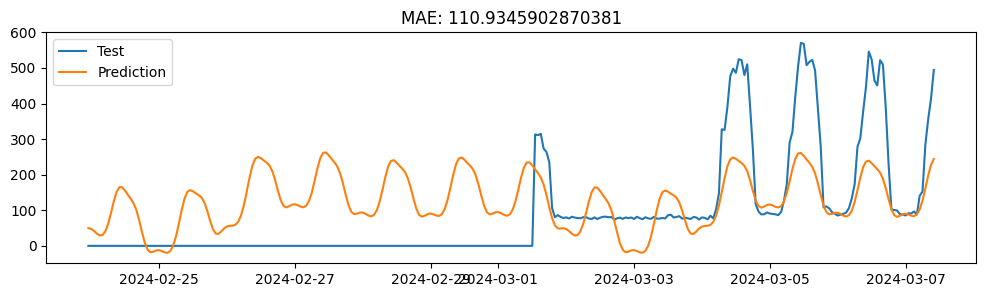

20:22:13 - cmdstanpy - INFO - Chain [1] start processing
20:22:13 - cmdstanpy - INFO - Chain [1] done processing


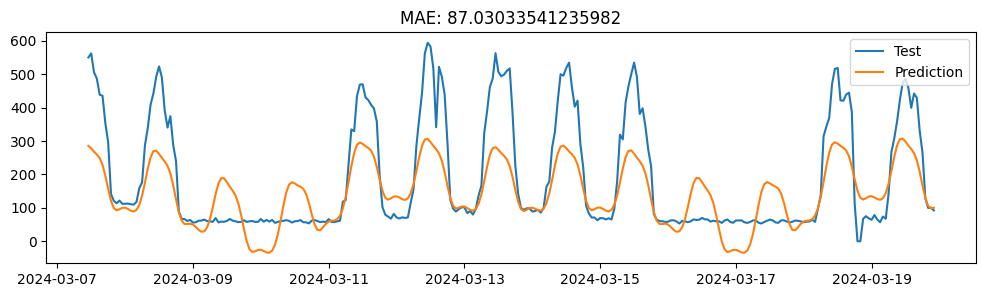

20:22:22 - cmdstanpy - INFO - Chain [1] start processing
20:22:22 - cmdstanpy - INFO - Chain [1] done processing


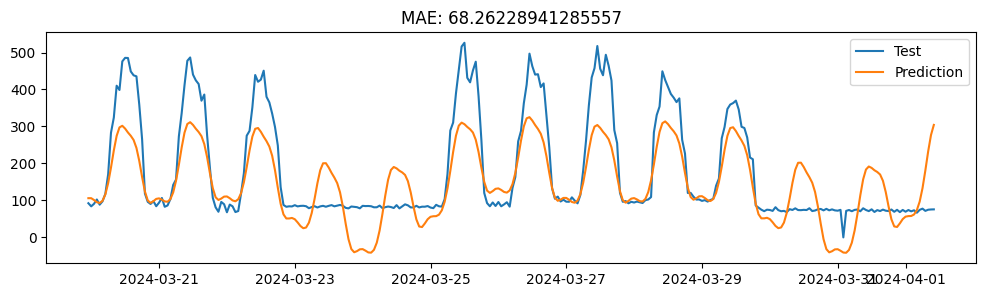

20:22:31 - cmdstanpy - INFO - Chain [1] start processing
20:22:31 - cmdstanpy - INFO - Chain [1] done processing


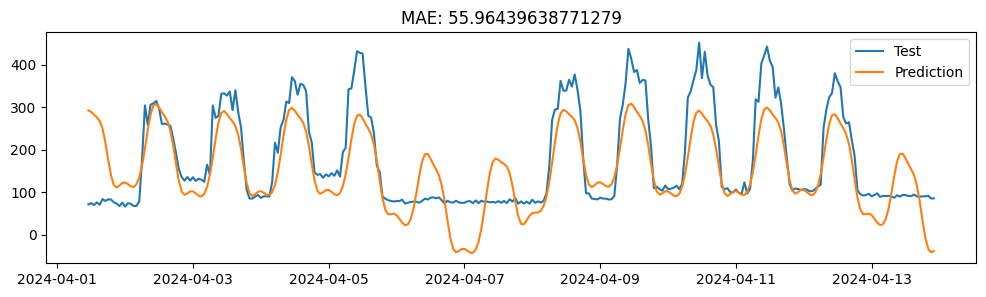

20:22:41 - cmdstanpy - INFO - Chain [1] start processing
20:22:41 - cmdstanpy - INFO - Chain [1] done processing


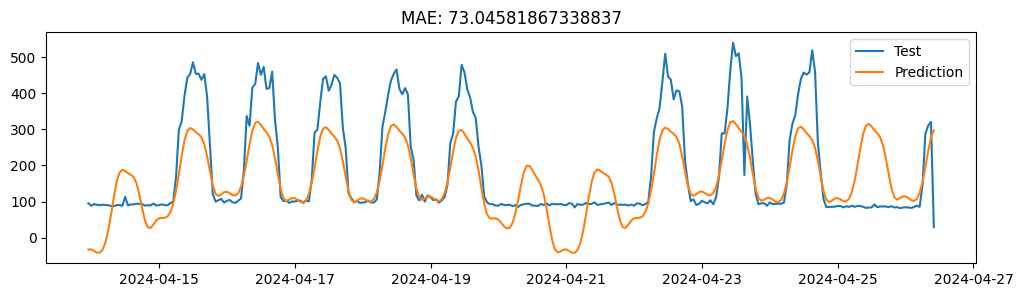

In [4]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

n_splits = 10
tscv = TimeSeriesSplit(
    n_splits=n_splits,
    test_size=300,
)

scores = []

for i, (train_index, test_index) in enumerate(tscv.split(df)):
    # Get the training and testing sets
    train_data = data.iloc[train_index]
    test_data = data.iloc[test_index]

    # train Prophet
    m = Prophet(
        growth="logistic",
        changepoint_prior_scale=0.004,
        n_changepoints=25,
        seasonality_mode="multiplicative",
        holidays_prior_scale=20,
        daily_seasonality=True,  # type: ignore
        weekly_seasonality=True,  # type: ignore
    )
    m.add_country_holidays("IT")
    m.fit(train_data)

    future = m.make_future_dataframe(periods=len(test_data), freq="h")
    future["floor"] = floor
    future["cap"] = cap

    forecast = m.predict(future)
    forecast = forecast.set_index("ds", drop=False)

    # only get the data pertaining to the test
    pred = forecast["yhat"][-len(test_data) :]

    # calculate the MAE for split
    score = mean_absolute_error(test_data["y"].values, pred.values)  # type: ignore
    scores.append(score)  # type: ignore

    plt.figure(figsize=(12, 3))
    plt.plot(test_data["y"], label="Test")
    plt.plot(pred, label="Prediction")
    plt.legend()
    plt.title(f"MAE: {scores[-1]}")

    plt.show()

In [6]:
print(f"Sum of scores: {sum(scores)}")
print(f"Avg of scores: {sum(scores)/len(scores)}")
print(f"Min of scores: {min(scores)}")
print(f"Max of scores: {max(scores)}")

Sum of scores: 881.7545050386537
Avg of scores: 88.17545050386538
Min of scores: 54.91392948904414
Max of scores: 151.44687973250564


## Train-test split


In [14]:
from sklearn.model_selection import train_test_split

# shuffle = False is necessary in timeseries in order to have the train set come before the test set
# source: https://datascience.stackexchange.com/questions/77635/proper-way-to-make-train-test-split-on-time-series
train, test = train_test_split(
    data,
    test_size=0.2,
    shuffle=False,
)

20:40:15 - cmdstanpy - INFO - Chain [1] start processing
20:40:16 - cmdstanpy - INFO - Chain [1] done processing
/home/impasse/.local/lib/python3.12/site-packages/prophet/plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/home/impasse/.local/lib/python3.12/site-packages/prophet/plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


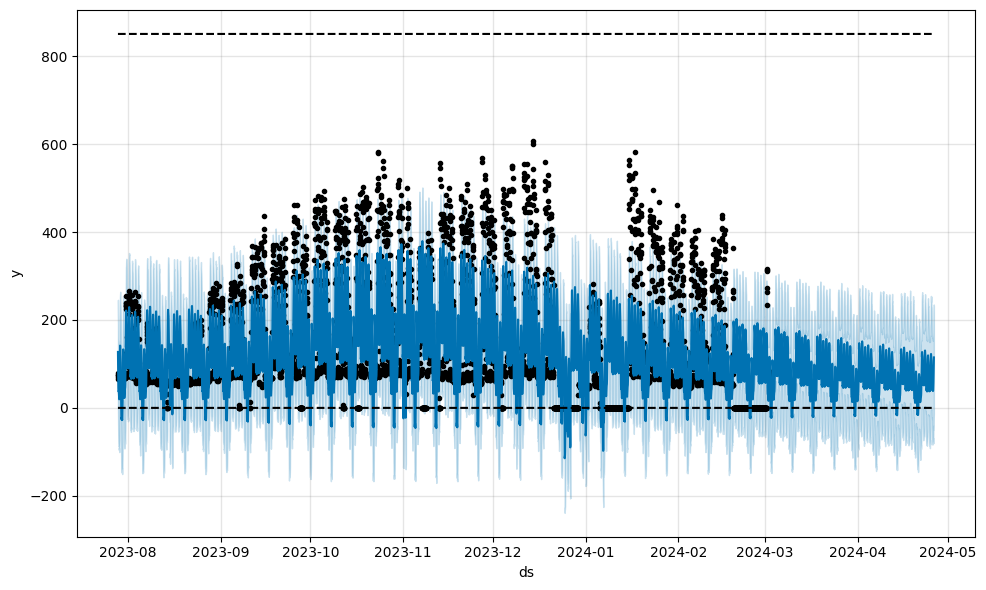

In [17]:
# train Prophet
m = Prophet(
    growth="logistic",
    changepoint_prior_scale=0.05,
    n_changepoints=5,
    seasonality_mode="multiplicative",
    holidays_prior_scale=20,
    daily_seasonality=True,  # type: ignore
    weekly_seasonality=True,  # type: ignore
)

m = m.add_country_holidays("IT")
m = m.fit(train)


future = m.make_future_dataframe(periods=len(test), freq="h")
future["floor"] = floor
future["cap"] = cap

forecast = m.predict(future)
forecast = forecast.set_index("ds", drop=False)

fig = m.plot(forecast)

Text(0.5, 1.0, 'MAE: 117.45087739709844')

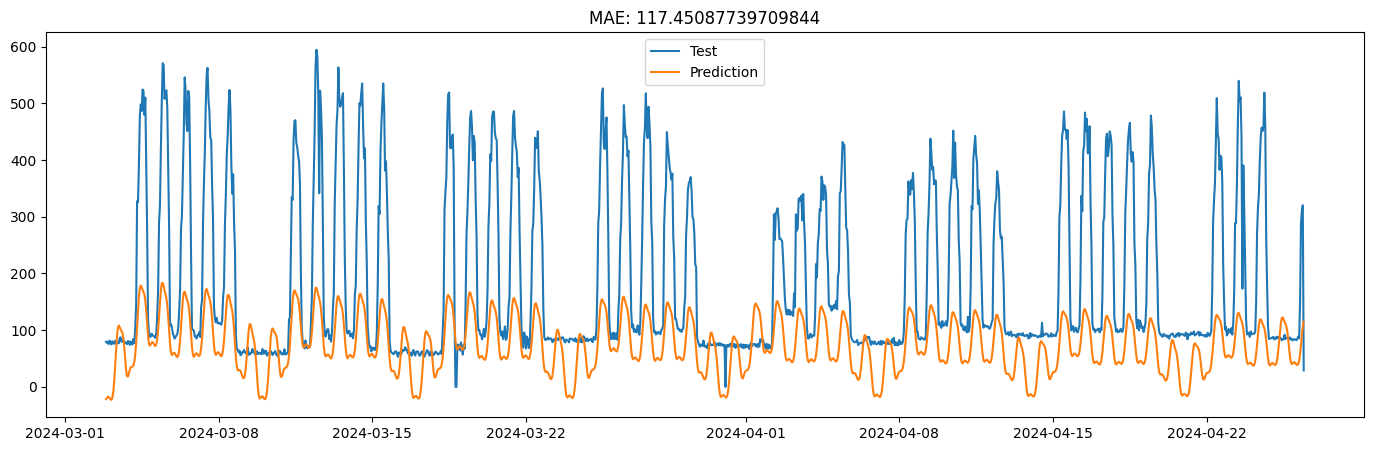

In [18]:
# only get the data pertaining to the test
pred = forecast["yhat"][-len(test) :]

score = mean_absolute_error(test["y"], pred)

plt.figure(figsize=(17, 5))
plt.plot(test["y"], label="Test")
plt.plot(pred, label="Prediction")
plt.legend()
plt.title(f"MAE: {score}")